In [11]:
import wandb
import pandas as pd

from matplotlib import pyplot as plt

In [12]:
api = wandb.Api(timeout=120)

In [13]:
# # Fetch runs from a specific project

# # run = api.run("gmum/bloraxs2/xys7m5o5")

# # exp_roberta_on_mrpc_svd_longrun roberta-large_mrpc_loraxs_seed3407_lr0.001_cls_lr0.005_ep201
# run = api.run("gmum/bloraxs2/5vpmkf6s")

# # exp_roberta_on_cola_svd_longrun roberta-large_cola_loraxs_seed3407_lr0.001_cls_lr0.005_ep201
# run = api.run("gmum/bloraxs2/2fxxqt7z")

# #exp_roberta_seed1410_on_cola_svd_longrun roberta-large_cola_loraxs_seed1410_lr0.001_cls_lr0.005_ep201
# run = api.run("gmum/bloraxs2/v0m2ehn6")

# #exp_roberta_on_rte_svd_longrun roberta-large_rte_loraxs_seed3407_lr0.001_cls_lr0.005_ep201
# run = api.run("gmum/bloraxs2/ef79o8w9")

In [14]:
run_names = {
    "mrpc":"gmum/bloraxs2/5vpmkf6s",
    "cola": "gmum/bloraxs2/2fxxqt7z",
    "cola (s=1410)": "gmum/bloraxs2/v0m2ehn6",
    "rte": "gmum/bloraxs2/ef79o8w9",
}

In [15]:
def extract_stats(df, dirs = ["map_metrics/", "laplace_LORAXS_KRON/", "laplace_LORAXS_DIAG/", "laplace/base_"]):
    ds = {}

    for dir in dirs:
        d = df[~df[f'{dir}epoch'].isna()]
        d = d[[c for c in d.columns if dir in c]]

        ds[dir] = d

    return ds

def load_and_extract(api, run_name):
    run = api.run(run_name)
    df = run.history(samples=100000)
    # print([f for f in list(df.columns) if "checkpoint" not in f])
    ds = extract_stats(df)
    return ds

In [16]:
data = {}
for title, run_name in run_names.items():
    data[run_name] = load_and_extract(api, run_name)

In [17]:
def plot_run(ds, markline=20):
    ds = ds.copy()

    fig, axes =plt.subplots(1,3, figsize=(15, 5))

    map = ds["map_metrics/"]
    del ds["map_metrics/"]

    plt.sca(axes[0])
    for stat in ["train_nll", "eval_nll"]:
        plt.plot(map["map_metrics/epoch"], map[f"map_metrics/{stat}"], label=stat)

    stat = "eval_nll"
    for dir, d in ds.items():
        plt.plot(d[f'{dir}epoch'], d[f'{dir}{stat}'], label=f"{dir}{stat}")
    plt.legend()
    plt.xlabel("Epoch")
    plt.grid(axis="x")

    plt.axvline(x=markline, color='gray', linestyle='--')
    # plt.xlim(0, 50)

    plt.sca(axes[1])
    for stat in ["train_ece", "eval_ece"]:
        plt.plot(map["map_metrics/epoch"], map[f"map_metrics/{stat}"], label=stat)

    stat = "eval_ece"
    for dir, d in ds.items():
        plt.plot(d[f'{dir}epoch'], d[f'{dir}{stat}'], label=f"{dir}{stat}")
    plt.legend()
    plt.xlabel("Epoch")
    plt.grid(axis="x")

    plt.axvline(x=markline, color='gray', linestyle='--')
    # plt.xlim(0, 50)

    plt.sca(axes[2])
    for stat in ["train_acc", "eval_acc"]:
        plt.plot(map["map_metrics/epoch"], map[f"map_metrics/{stat}"], label=stat)

    stat = "eval_acc"
    for dir, d in ds.items():
        plt.plot(d[f'{dir}epoch'], d[f'{dir}{stat}'], label=f"{dir}{stat}")
    plt.legend()
    plt.xlabel("Epoch")
    plt.grid(axis="x")

    plt.axvline(x=markline, color='gray', linestyle='--')
    # plt.xlim(0, 50)



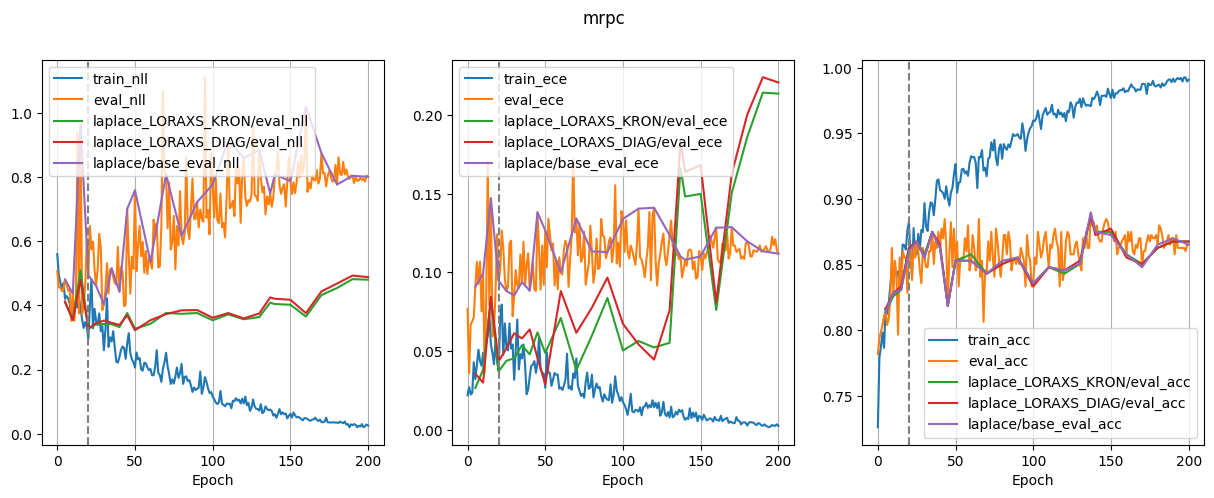

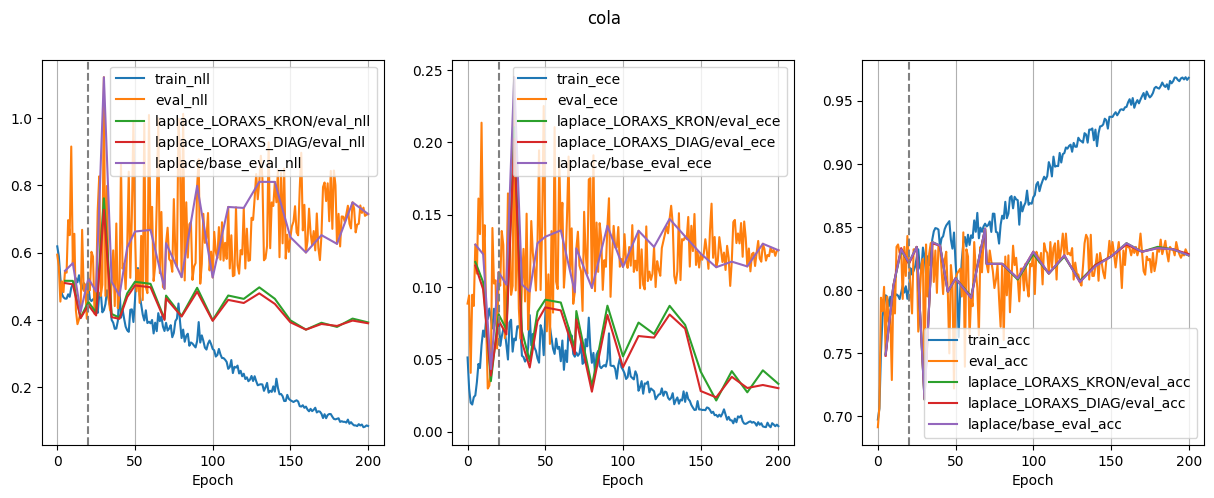

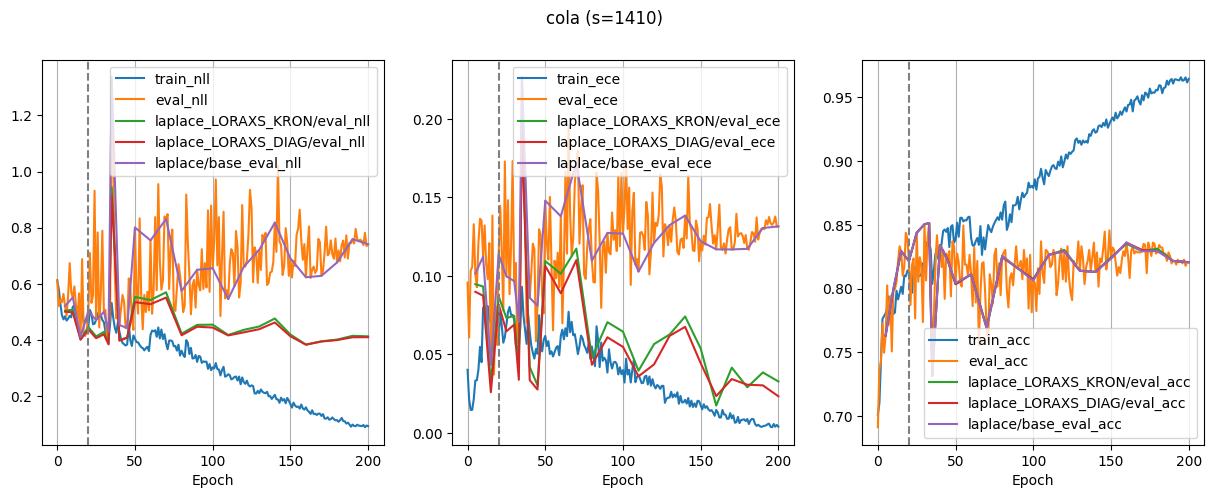

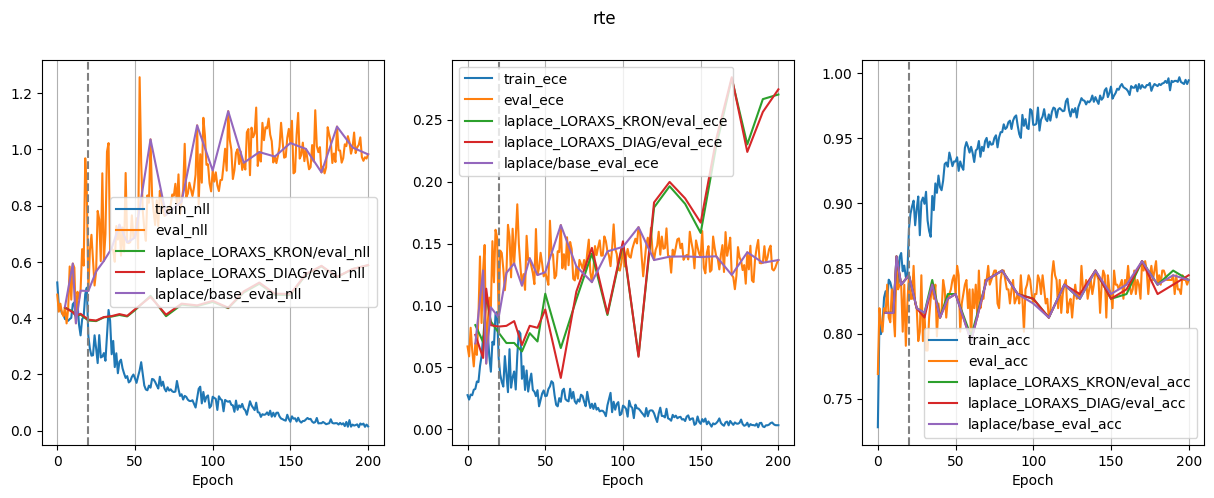

In [18]:
for title, run_name in run_names.items():
    ds = data[run_name]
    # print(f"Run: {run_name}")
    plot_run(ds)
    plt.suptitle(title)
    plt.show()